<a href="https://colab.research.google.com/github/Vimukthi-Nuwan/Deep_Learning/blob/Experiment/Fashion_MNIST/DL_Challenge_1_Final_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 📌 Import necessary libraries

In [ ]:
import keras
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from keras import layers
from keras import Sequential
from keras.layers import Dense
from keras.datasets import fashion_mnist
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### 📌 Load the Fashion MNIST dataset (grayscale 28x28 images of clothing items)

In [ ]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

### ✅ Ensure the data is correctly shaped

In [ ]:
assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

### 📌 Normalize pixel values between 0 and 1 (improves training stability)
➡️ This helps the model learn faster and prevents large weight updates

In [ ]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

### 📌 Reshape input data to add a single grayscale channel
➡️ CNN expects a 4D input (batch_size, height, width, channels)

In [ ]:
x_train = np.expand_dims(x_train, axis=-1)  # Shape: (60000, 28, 28, 1)
x_test = np.expand_dims(x_test, axis=-1)  # Shape: (10000, 28, 28, 1)

### 📌 One-hot encode the output labels (required for categorical classification)
➡️ Converts class labels (0-9) into a 10-element vector (one-hot encoding)

In [ ]:
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

### 📌 Define the CNN model (Convolutional Neural Network)

In [ ]:
model = Sequential([

    # 🔹 First Convolutional Block
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),  # 32 filters, 3x3 kernel
    layers.MaxPool2D((2,2)),  # Reduces dimensions (Pooling layer)

    # 🔹 Second Convolutional Block
    layers.Conv2D(64, (3,3), activation='relu'),  # 64 filters, 3x3 kernel
    layers.MaxPool2D((2,2)),  # Reduces dimensions again

    # 🔹 Third Convolutional Block
    layers.Conv2D(128, (3,3), activation='relu'),  # 128 filters, 3x3 kernel

    # 🔹 Fully Connected Layers
    layers.Flatten(),  # Converts 2D feature maps into 1D

    layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.00005)),  # 256 neurons
    layers.BatchNormalization(),  # Normalizes activations for stable learning
    layers.Dropout(0.2),  # Prevents overfitting (20% dropout)

    layers.Dense(128, activation="relu", kernel_regularizer=keras.regularizers.l2(0.00005)),  # 128 neurons
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(64, activation="relu", kernel_regularizer=keras.regularizers.l2(0.00005)),  # 64 neurons
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(10, activation="softmax")  # Output layer (10 classes)
])

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 📌 Data Augmentation (Randomly modifies training images to improve generalization)

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=5,  # Randomly rotate images by 5 degrees
    width_shift_range=0.05,  # Shift width by 5% (horizontal shift)
    height_shift_range=0.05,  # Shift height by 5% (vertical shift)
    shear_range=0.03,  # Shear transformation (warping effect)
    zoom_range=0.03,  # Zoom-in/out by 3%
    horizontal_flip=True,  # Flip images horizontally
    fill_mode='nearest'  # Fill missing pixels using the nearest value
)

### 📌 Fit augmentation generator to training data

In [ ]:
datagen.fit(x_train)

### 📌 Compile the model (Define loss function, optimizer, and evaluation metric)

In [ ]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=8e-5),  # Learning rate 0.00008
              loss='categorical_crossentropy',  # Multi-class classification loss
              metrics=['accuracy'])  # Track accuracy during training

### 📌 Define Learning Rate Reduction Strategy
🔹 If validation loss stops improving for 2 epochs, reduce LR by 50%

In [ ]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

### Train the model

In [ ]:
# 📌 Train the model
history = model.fit(datagen.flow(x_train, y_train, batch_size=64),  # Use augmented data
                    epochs=50,  # Train for 50 epochs
                    validation_data=(x_test, y_test),  # Evaluate on test data
                    callbacks=[reduce_lr])  # Use learning rate reduction strategy

Epoch 1/50


/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.5895 - loss: 1.2572 - val_accuracy: 0.7907 - val_loss: 0.6255 - learning_rate: 8.0000e-05
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.7678 - loss: 0.6789 - val_accuracy: 0.8292 - val_loss: 0.5123 - learning_rate: 8.0000e-05
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8056 - loss: 0.5715 - val_accuracy: 0.8419 - val_loss: 0.4670 - learning_rate: 8.0000e-05
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8261 - loss: 0.5115 - val_accuracy: 0.8670 - val_loss: 0.4040 - learning_rate: 8.0000e-05
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8386 - loss: 0.4799 - val_accuracy: 0.8732 - val_loss: 0.3901 - learning_rate: 8.0000e-05
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.8475 - loss: 0.4443 - val_accuracy: 0.8819 - val_loss: 0.3623 - learning_rate: 8.0000e-05
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accurac

### 📌 Plot Training and Validation Accuracy Over Epochs

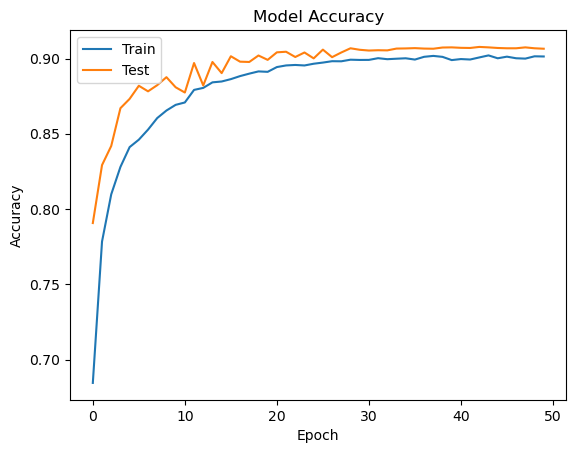

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

### 📌 Plot Training and Validation Loss Over Epochs

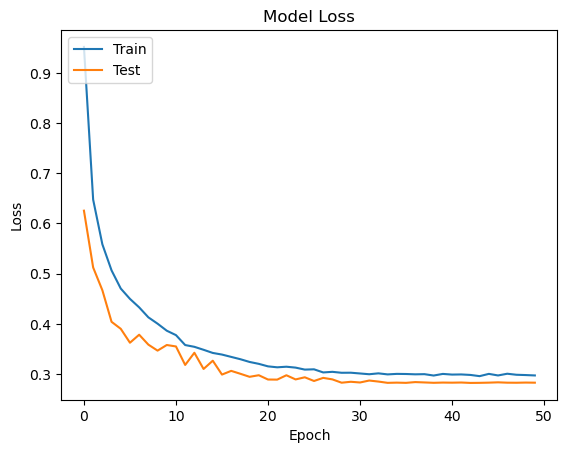

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

### 📌 Predict Class Probabilities on Test Data

In [ ]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


### 📌 Convert Predicted Probabilities to Class Labels

In [ ]:
y_pred_labels = np.argmax(y_pred, axis=1)

### 📌 Convert One-Hot Encoded `y_test` Back to Class Labels

In [ ]:
y_test_labels = np.argmax(y_test, axis=1)

### 📌 Calculate Accuracy of the Model on Test Data

In [ ]:
acc = accuracy_score(y_test_labels, y_pred_labels)
print(f"Validation Accuracy Score: {acc:.4f}")

Validation Accuracy Score: 0.9065


### 📌 Print Classification Report (Precision, Recall, F1-score for Each Class)

In [ ]:
print(classification_report(y_test_labels, y_pred_labels))

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1000
           1       1.00      0.98      0.99      1000
           2       0.89      0.84      0.86      1000
           3       0.90      0.92      0.91      1000
           4       0.84      0.85      0.85      1000
           5       0.97      0.98      0.98      1000
           6       0.71      0.76      0.74      1000
           7       0.94      0.96      0.95      1000
           8       0.98      0.98      0.98      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



### 📌 Compute Confusion Matrix

In [ ]:
conf_matrix = confusion_matrix(y_test_labels, y_pred_labels)

### 📌 Plot Confusion Matrix Using Seaborn Heatmap

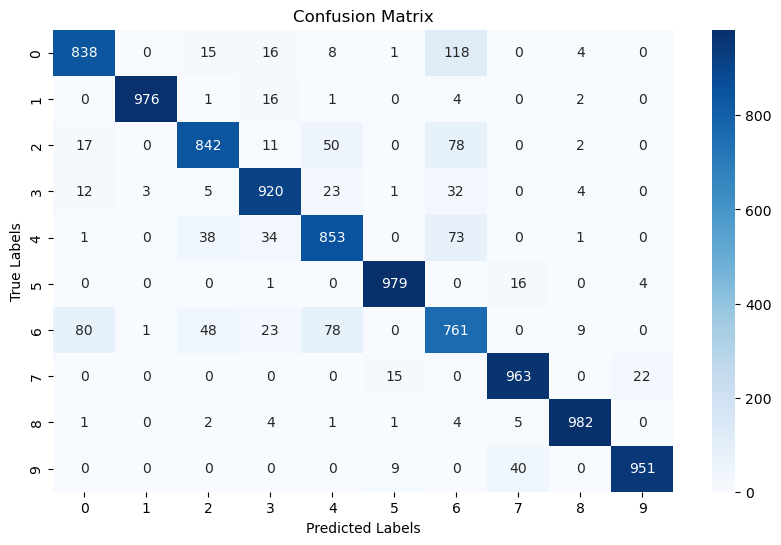

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()